# Non-Stationary Data Analysis for GS-GLS

This notebook evaluates GS-GLS on non-stationary (heteroscedastic) data using the new Wavelet Temporal Estimation.

We introduce a Temporal Hierarchy (Daily -> Total) to ensure temporal covariance influences the reconciliation.

Data Shapes: Y_hat (15, 129), S_tm (129, 128)


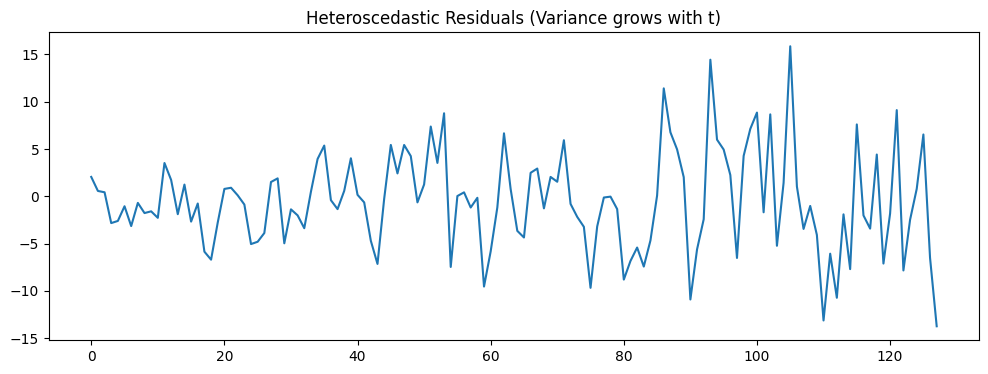

In [1]:
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from hierarchy import Hierarchy
from data_generator import HierarchicalDataGenerator
from gs_gls import GSGLS

np.random.seed(42)
# Manually define a binary tree structure for 8 bottom nodes
# Root(0) -> 1,2 -> (3,4), (5,6) -> (7..14)
structure = {
    0: [1, 2],
    1: [3, 4], 2: [5, 6],
    3: [7, 8], 4: [9, 10], 5: [11, 12], 6: [13, 14]
}
hierarchy = Hierarchy(structure)
n_bottom = hierarchy.m_bottom # Should be 8

# Use power of 2 for Wavelet simplicity (though not strictly required with dec)
n_timesteps = 128 
generator = HierarchicalDataGenerator(hierarchy, n_timesteps)

# 1. Generate Ground Truth (Bottom only)
Y_truth_bottom = generator.generate_ground_truth()

# 2. Generate Heteroscedastic Residuals (Bottom)
E_bottom = generator.generate_spatiotemporal_noise(
    spatial_rho=1.5, 
    temporal_ar_coefs=[0.5], 
    noise_scale=2.0, 
    heteroscedastic=True
)

Y_hat_bottom = Y_truth_bottom + E_bottom

# 3. Construct Temporal Hierarchy: [Bottom(128); Total(1)]
# Map 128 -> 129
S_tm = np.vstack([np.eye(n_timesteps), np.ones((1, n_timesteps))])

# Truth Full
Y_truth = Y_truth_bottom @ S_tm.T

# Generate Independent Noise for the Total (Top Temporal Node)
# Assume Total is forecasted with some error, not just Sum of Bottom Forecasts
E_total = np.random.normal(0, np.sqrt(n_timesteps)*2.0, (hierarchy.n_nodes, 1))

# Full Residuals
E_full = np.hstack([E_bottom, E_total])
Y_hat = Y_truth + E_full

print(f"Data Shapes: Y_hat {Y_hat.shape}, S_tm {S_tm.shape}")

plt.figure(figsize=(12, 4))
plt.plot(E_bottom[0, :], label='Node 0 Residuals')
plt.title("Heteroscedastic Residuals (Variance grows with t)")
plt.show()

In [2]:
# --- Evaluation Helper ---
def eval_mse(Y_rec, Y_true):
    return np.mean((Y_rec - Y_true)**2)

# 1. GS-GLS (Spectral)
# Note: Spectral assumes stationarity (Toeplitz). 
# It will average the variance across time.
gs_spectral = GSGLS(hierarchy, temporal_method='spectral')
gs_spectral.fit(E_full, S_tm=S_tm)
Y_sp = gs_spectral.reconcile(Y_hat)
mse_sp = eval_mse(Y_sp, Y_truth)
print(f"GS-GLS (Spectral) MSE: {mse_sp:.4f}")

# 2. GS-GLS (Wavelet)
# Wavelet should handle non-stationarity (varying variance).
gs_wavelet = GSGLS(hierarchy, temporal_method='wavelet')
gs_wavelet.fit(E_full, S_tm=S_tm)
Y_wv = gs_wavelet.reconcile(Y_hat)
mse_wv = eval_mse(Y_wv, Y_truth)
print(f"GS-GLS (Wavelet) MSE: {mse_wv:.4f}")

# Comparison
imp = (mse_sp - mse_wv) / mse_sp * 100
print(f"Improvement: {imp:.2f}%")

GS-GLS (Spectral) MSE: 37.7465
GS-GLS (Wavelet) MSE: 21.8089
Improvement: 42.22%


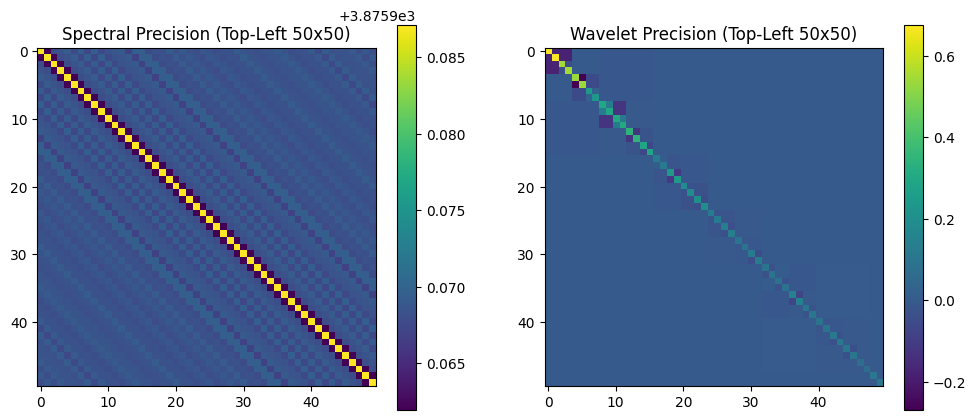

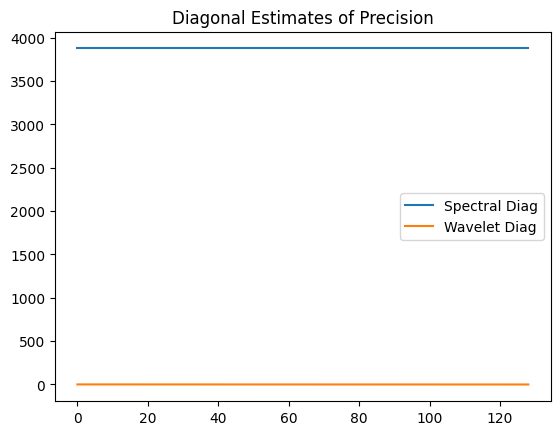

In [3]:
# Visualizing the Precision Matrices (Diagonal)
# We expect Wavelet precision to decrease over time (as variance increases).
# Spectral precision (diagonal of inverse? No, typically stationary).

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(gs_spectral.temporal_prec_matrix[:50, :50], cmap='viridis')
plt.title("Spectral Precision (Top-Left 50x50)")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(gs_wavelet.temporal_prec_matrix[:50, :50], cmap='viridis')
plt.title("Wavelet Precision (Top-Left 50x50)")
plt.colorbar()
plt.show()

# Check diagonals
plt.figure()
plt.plot(np.diag(gs_spectral.temporal_prec_matrix), label='Spectral Diag')
plt.plot(np.diag(gs_wavelet.temporal_prec_matrix), label='Wavelet Diag')
plt.legend()
plt.title("Diagonal Estimates of Precision")
plt.show()